# CIFAR-10 Image Classification: ANN vs CNN

**Part of:** [SaviortheCoder/machine-learning-portfolio](https://github.com/SaviortheCoder/machine-learning-portfolio)  
**Folder:** 

## Objective
- Build and compare two neural network architectures for image classification on the CIFAR-10 dataset
- **ANN (Artificial Neural Network):** flattens images into 1-D vectors, fully-connected Dense layers
- **CNN (Convolutional Neural Network):** preserves 2-D spatial structure, convolutional + pooling layers
- Understand *why* CNNs outperform ANNs on image data

## Results
| Model | Train Acc (Ep 10) | Val Acc (Ep 10) | Test Loss |
|-------|------------------|-----------------|----------|
| ANN   | 51.78%           | 48.88%          | 1.4233   |
| CNN   | 76.58%           | 69.28%          | 0.9122   |

> CNN outperforms ANN by **+20 percentage points** using **19× fewer parameters**.


## Setup & Imports

In [ ]:
# Install dependencies if needed
# !pip install tensorflow visualkeras

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np


## Load CIFAR-10 Dataset

In [ ]:
# cifar10.load_data() returns:
#   x_train/x_test : image arrays  shape (N, 32, 32, 3)  — uint8 pixel values 0-255
#   y_train/y_test : label arrays  shape (N, 1)          — integer class 0-9
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)


(50000, 32, 32, 3) (10000, 32, 32, 3) (50000, 1) (10000, 1)


/Users/thtblkboy/miniforge3/envs/ml_class/lib/python3.11/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


### What do the shape numbers mean?
- **(50000, 32, 32, 3):** 50,000 training images, each 32×32 pixels with 3 colour channels (RGB)
- **(10000, 32, 32, 3):** 10,000 test images, same dimensions
- **(50000, 1):** 50,000 training labels — one integer (0–9) per image
- **(10000, 1):** 10,000 test labels — one integer per image


## Data Exploration

In [ ]:
# A single image is a 32×32 grid of [R, G, B] triplets (uint8, range 0-255)
x_train[0]


array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

### Visualize Sample Images

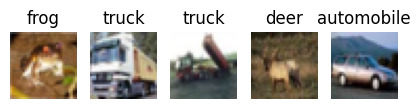

In [ ]:
class_names = ["airplane","automobile","bird","cat","deer",
               "dog","frog","horse","ship","truck"]

# Show first 5 training images
plt.figure(figsize=(5,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.suptitle("First 5 Training Images", y=1.05)
plt.show()


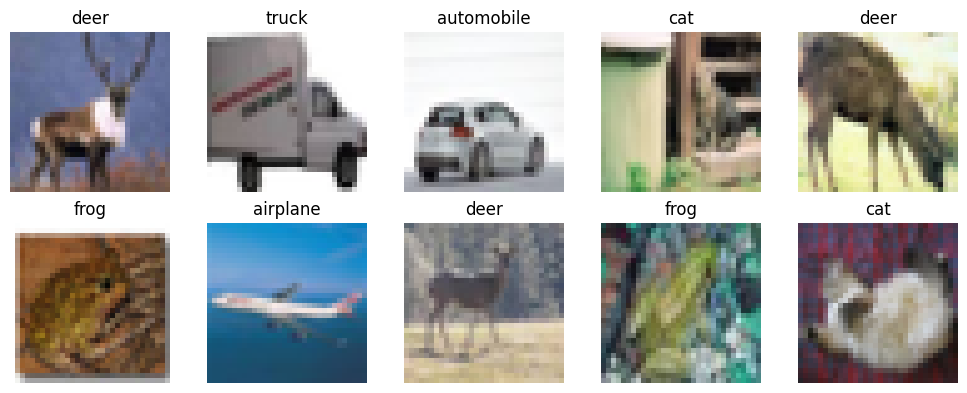

In [ ]:
# Show 10 random training images — re-run to see different samples
plt.figure(figsize=(10,4))
random_indices = np.random.randint(0, len(x_train), 10)
for i, idx in enumerate(random_indices):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[idx])
    plt.title(class_names[y_train[idx][0]])
    plt.axis("off")
plt.suptitle("10 Random Training Images", y=1.02)
plt.tight_layout()
plt.show()


---
## Part 1: Artificial Neural Network (ANN)

An ANN treats each image as a flat **1-D vector of numbers**.
For a 32×32 RGB image: 32 × 32 × 3 = **3,072 input features**.
Fully-connected Dense layers learn weights between every input and every neuron —
but this destroys all spatial relationships between pixels.


In [ ]:
from tensorflow.keras import models
from tensorflow.keras.layers import Dense


### 1.1 Preprocessing — Flatten, Normalize, One-Hot Encode

In [ ]:
# STEP 1 — FLATTEN
# ANN needs 1-D input: reshape (N, 32, 32, 3) → (N, 3072)
num_pixels = x_train.shape[1] * x_train.shape[2] * x_train.shape[3]  # 32*32*3 = 3072
print("Features per image:", num_pixels)

x_train_ann = x_train.reshape(x_train.shape[0], num_pixels).astype("float32")
x_test_ann  = x_test.reshape(x_test.shape[0],  num_pixels).astype("float32")
print(x_train_ann.shape, x_test_ann.shape)


Features per image: 3072
(50000, 3072) (10000, 3072)


In [ ]:
# STEP 2 — NORMALIZE: pixel values 0-255 → 0.0-1.0
# Small inputs help the network train faster and avoid large gradient updates
x_train_ann = x_train_ann / 255.0
x_test_ann  = x_test_ann  / 255.0

# STEP 3 — ONE-HOT ENCODE LABELS
# Integer label (e.g. 3 = cat) → 10-element vector [0,0,0,1,0,0,0,0,0,0]
# Required for categorical_crossentropy loss
y_train_ann = to_categorical(y_train)   # (50000,) → (50000, 10)
y_test_ann  = to_categorical(y_test)    # (10000,)  → (10000, 10)
print(x_train_ann.shape, y_train_ann.shape)  # (50000, 3072) (50000, 10)


(50000, 3072) (50000, 10)


### 1.2 Build ANN Model

In [ ]:
from tensorflow.keras.layers import Input

num_classes = 10

def simplenn_model():
    """3-hidden-layer fully-connected ANN for CIFAR-10 classification."""
    model = models.Sequential([
        # Explicit Input layer (avoids deprecation warning)
        Input(shape=(num_pixels,)),
        # Hidden layer 1: 1000 neurons, ReLU activation
        Dense(1000, activation="relu", kernel_initializer="normal"),
        # Hidden layer 2: 100 neurons, ReLU activation
        Dense(100,  activation="relu", kernel_initializer="normal"),
        # Hidden layer 3: 50 neurons, ReLU activation
        Dense(50,   activation="relu", kernel_initializer="normal"),
        # Output layer: 10 neurons (one per class), softmax → probabilities
        Dense(num_classes, activation="softmax", kernel_initializer="normal"),
    ])
    # categorical_crossentropy: standard loss for one-hot multi-class problems
    # adam: adaptive learning rate optimiser
    model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
    return model

ann_model = simplenn_model()
ann_model.summary()


### 1.3 Train ANN

In [ ]:
# epochs=10     : 10 full passes over training data
# batch_size=200 : update weights after every 200 images
# validation_data: evaluate on test set after each epoch to monitor overfitting
ann_history = ann_model.fit(
    x_train_ann, y_train_ann,
    validation_data=(x_test_ann, y_test_ann),
    epochs=10,
    batch_size=200,
    verbose=2
)


Epoch 1/10


/Users/thtblkboy/miniforge3/envs/ml_class/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 - 2s - 8ms/step - accuracy: 0.3026 - loss: 1.9101 - val_accuracy: 0.3455 - val_loss: 1.8232
Epoch 2/10
250/250 - 2s - 7ms/step - accuracy: 0.3870 - loss: 1.7082 - val_accuracy: 0.4041 - val_loss: 1.6413
Epoch 3/10
250/250 - 2s - 7ms/step - accuracy: 0.4236 - loss: 1.6154 - val_accuracy: 0.4295 - val_loss: 1.6013
Epoch 4/10
250/250 - 2s - 7ms/step - accuracy: 0.4482 - loss: 1.5516 - val_accuracy: 0.4628 - val_loss: 1.5093
Epoch 5/10
250/250 - 2s - 7ms/step - accuracy: 0.4604 - loss: 1.5121 - val_accuracy: 0.4683 - val_loss: 1.5016
Epoch 6/10
250/250 - 2s - 7ms/step - accuracy: 0.4775 - loss: 1.4635 - val_accuracy: 0.4733 - val_loss: 1.4825
Epoch 7/10
250/250 - 2s - 7ms/step - accuracy: 0.4889 - loss: 1.4353 - val_accuracy: 0.4735 - val_loss: 1.4926
Epoch 8/10
250/250 - 2s - 8ms/step - accuracy: 0.5028 - loss: 1.3998 - val_accuracy: 0.4860 - val_loss: 1.4382
Epoch 9/10
250/250 - 2s - 8ms/step - accuracy: 0.5099 - loss: 1.3811 - val_accuracy: 0.4712 - val_loss: 1.4919
Epoch 10/10


### ANN Last Epoch Accuracy
**Training accuracy (Epoch 10):** 51.78%  
**Validation accuracy (Epoch 10):** 48.88%

> The small gap (~3%) between train and val accuracy means the model is not heavily overfitting,
> but overall performance is low because flattening destroys spatial information.


### 1.4 Evaluate ANN

In [ ]:
ann_model.summary()
print("
Test [loss, accuracy]:", ann_model.evaluate(x_test_ann, y_test_ann, verbose=0))


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4888 - loss: 1.4233
[1.4233307838439941, 0.4887999892234802]


In [ ]:
from sklearn.metrics import classification_report

# Convert one-hot back to integer labels for the report
y_true = np.argmax(y_test_ann, axis=1)
y_pred = np.argmax(ann_model.predict(x_test_ann, verbose=0), axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

    airplane       0.66      0.47      0.55      1000
  automobile       0.67      0.58      0.62      1000
        bird       0.42      0.35      0.38      1000
         cat       0.29      0.53      0.38      1000
        deer       0.57      0.22      0.32      1000
         dog       0.45      0.25      0.32      1000
        frog       0.47      0.61      0.53      1000
       horse       0.60      0.52      0.55      1000
        ship       0.57      0.70      0.63      1000
       truck       0.46      0.66      0.54      1000

    accuracy                           0.49     10000
   macro avg       0.52      0.49      0.48     10000
weighted avg       0.52      0.49      0.48     10000



### 1.5 ANN Training History

In [ ]:
# Visualising accuracy and loss curves helps diagnose overfitting:
# If train >> val → overfitting. If both are low → underfitting.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ann_history.history["accuracy"],     label="Train")
axes[0].plot(ann_history.history["val_accuracy"], label="Validation")
axes[0].set_title("ANN — Accuracy per Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(ann_history.history["loss"],     label="Train")
axes[1].plot(ann_history.history["val_loss"], label="Validation")
axes[1].set_title("ANN — Loss per Epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()


---
## Part 2: Convolutional Neural Network (CNN)

A CNN keeps the **2-D spatial structure** of the image intact.
Instead of fully-connected layers, it uses **convolutional filters** that slide across
the image and detect local patterns (edges → textures → shapes → objects).
MaxPooling then down-samples feature maps, keeping only the strongest signals.


In [ ]:
%matplotlib inline
import tensorflow.keras as keras
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input
from tensorflow.keras import layers, models
from tensorflow.keras import backend as K


### 2.1 Reload & Reshape for CNN

In [ ]:
# Reload fresh copy — CNN keeps 2-D structure, no flattening
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)


(50000, 32, 32, 3) (10000, 32, 32, 3) (50000, 1) (10000, 1)


/Users/thtblkboy/miniforge3/envs/ml_class/lib/python3.11/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [ ]:
# Detect backend channel ordering:
#   TensorFlow (default): channels_last  → shape (N, H, W, C)
#   Theano               : channels_first → shape (N, C, H, W)
img_rows, img_cols = x_train.shape[1], x_train.shape[2]  # 32, 32
channel = x_train.shape[3]  # 3 (RGB)

if K.image_data_format() == "channels_first":
    x_train = x_train.reshape(x_train.shape[0], channel, img_rows, img_cols)
    x_test  = x_test.reshape(x_test.shape[0],   channel, img_rows, img_cols)
    input_shape = (channel, img_rows, img_cols)  # (3, 32, 32)
    print("channels_first")
else:
    x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, channel)
    x_test  = x_test.reshape(x_test.shape[0],   img_rows, img_cols, channel)
    input_shape = (img_rows, img_cols, channel)  # (32, 32, 3) — TF default
    print("channels_last")


it was channels_last


### 2.2 Preprocessing — Normalize & One-Hot Encode

In [ ]:
# Same normalization as ANN — pixel values 0-255 → 0.0-1.0
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

# One-hot encode labels
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test  = keras.utils.to_categorical(y_test,  num_classes)
print(y_test[:3])  # Each row: 10-element vector, 1 in the correct class position


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]]


### 2.3 Build CNN Model

In [ ]:
cnn_model = models.Sequential([
    Input(shape=input_shape),                          # (32, 32, 3)
    Conv2D(32, (3,3), activation="relu"),              # 32 filters → detects low-level features
    MaxPooling2D(pool_size=(2,2)),                     # halve spatial dims: 30×30 → 15×15
    Conv2D(64, (3,3), activation="relu"),              # 64 filters → detects higher-level features
    MaxPooling2D(pool_size=(2,2)),                     # halve again: 13×13 → 6×6
    Flatten(),                                         # 6×6×64 = 2304 → 1-D vector
    Dense(64,  activation="relu"),                    # learn combinations of features
    Dense(10,  activation="softmax"),                 # output: probability for each of 10 classes
])

cnn_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

### 2.4 Compile & Train CNN

In [ ]:
cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
# batch_size=64  : smaller than ANN (CNN has more compute per step)
# epochs=10      : same as ANN for fair comparison
cnn_history = cnn_model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=10,
    validation_data=(x_test, y_test)
)


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.4372 - loss: 1.5689 - val_accuracy: 0.5401 - val_loss: 1.3142
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5763 - loss: 1.2017 - val_accuracy: 0.5739 - val_loss: 1.2099
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6265 - loss: 1.0662 - val_accuracy: 0.6371 - val_loss: 1.0573
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6620 - loss: 0.9695 - val_accuracy: 0.6433 - val_loss: 1.0357
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6857 - loss: 0.9036 - val_accuracy: 0.6703 - val_loss: 0.9566
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7071 - loss: 0.8438 - val_accuracy: 0.6507 - val_loss: 1.0161
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7244 - loss: 0.7956 - val_accuracy: 0.6863 - val_loss: 0.9247
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.7395 - loss: 0.7499 - val_accuracy: 0.

### CNN Last Epoch Accuracy
**Training accuracy (Epoch 10):** 76.58%  
**Validation accuracy (Epoch 10):** 69.28%

> The ~7% train/val gap shows mild overfitting — the CNN is learning some patterns
> specific to training data. Still, 69.28% is a dramatic improvement over the ANN.


### 2.5 Evaluate CNN

In [ ]:
print("Test [loss, accuracy]:", cnn_model.evaluate(x_test, y_test, verbose=0))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6928 - loss: 0.9122
[0.9122291207313538, 0.692799985408783]


### 2.6 Visualize CNN Architecture

/Users/thtblkboy/miniforge3/envs/ml_class/lib/python3.11/site-packages/visualkeras/layered.py:231: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


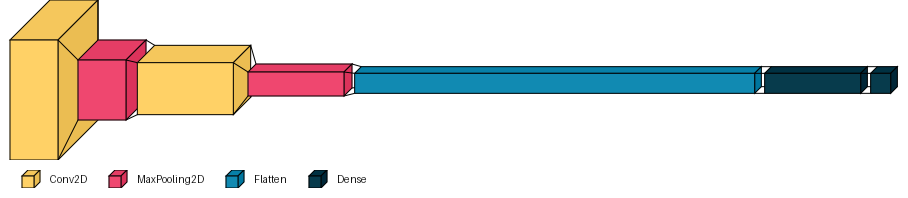

In [ ]:
import visualkeras  # pip install visualkeras
for layer in cnn_model.layers:
    layer.output_shape = layer.output.shape
visualkeras.layered_view(cnn_model, legend=True)


### 2.7 CNN Training History

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(cnn_history.history["accuracy"],     label="Train")
axes[0].plot(cnn_history.history["val_accuracy"], label="Validation")
axes[0].set_title("CNN — Accuracy per Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(cnn_history.history["loss"],     label="Train")
axes[1].plot(cnn_history.history["val_loss"], label="Validation")
axes[1].set_title("CNN — Loss per Epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()


---
## Comparison: ANN vs CNN

### Results
| Model | Trainable Params | Train Acc | Val Acc  | Test Loss |
|-------|-----------------|-----------|----------|----------|
| ANN   | 3,178,660       | 51.78%    | 48.88%   | 1.4233   |
| CNN   | 167,562         | 76.58%    | 69.28%   | 0.9122   |

### Why CNN wins on images

1. **Spatial structure preserved.** The ANN flattens each 32×32×3 image into 3,072 numbers, discarding all information about *where* pixels sit relative to each other. The CNN keeps the 2-D grid and slides filters across it, so position matters.

2. **Hierarchical feature learning.** Conv layers build up from simple (edges, colours) to complex (textures, shapes, object parts) features. An ANN has no such hierarchy — it tries to learn everything in one step from raw pixels.

3. **Translation invariance.** MaxPooling makes the CNN tolerant of small positional shifts. A cat's ear 3 pixels to the left is still recognised as an ear. An ANN would treat it as a completely different input.

4. **19× fewer parameters, 20% better accuracy.** ANN: 3.17M params → 48.9% accuracy. CNN: 167K params → 69.3% accuracy. Weight sharing in conv filters is dramatically more efficient than fully-connected layers.

5. **ANN struggles most on visually similar classes.** The classification report shows ANN scored lowest on deer (F1=0.32), dog (0.32), and cat (0.38) — animals requiring fine-grained spatial and textural discrimination. CNN handles these far better by design.
